In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



In [3]:
data = pd.read_csv("../data/file.csv")
data.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [4]:
data.tail()

,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


In [5]:
data.shape

(185, 5)

In [6]:
data.info

<bound method DataFrame.info of        Date   Open   High    Low  Close
0    Jul-05  13.00  14.00  11.25  12.46
1    Aug-05  12.58  14.88  12.55  13.42
2    Sep-05  13.48  14.87  12.27  13.30
3    Oct-05  13.20  14.47  12.40  12.99
4    Nov-05  13.35  13.88  12.88  13.41
..      ...    ...    ...    ...    ...
180  Jul-20  25.60  28.30  11.10  11.95
181  Aug-20  12.00  17.16  11.85  14.37
182  Sep-20  14.30  15.34  12.75  13.15
183  Oct-20  13.30  14.01  12.11  12.42
184  Nov-20  12.41  14.90  12.21  14.67

[185 rows x 5 columns]>

In [7]:
#converting data into datatime format
data["Date"] = pd.to_datetime(data["Date"],format="%b-%y")
data = data.sort_values("Date").reset_index(drop=True)
data.head()


,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


In [8]:
#check null value
data.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [9]:
#check dublicate
data.duplicated().sum()

np.int64(0)

In [10]:
#basic statistics
data.describe()

,Date,Open,High,Low,Close
count,185,185.000000,185.000000,185.000000,185.000000
mean,2013-03-01 19:04:12.972973056,105.541405,116.104324,94.947838,105.204703
min,2005-07-01 00:00:00,10.000000,11.240000,5.550000,9.980000
25%,2009-05-01 00:00:00,33.800000,36.140000,28.510000,33.450000
50%,2013-03-01 00:00:00,62.980000,72.550000,58.000000,62.540000
75%,2017-01-01 00:00:00,153.000000,169.190000,138.350000,153.300000
max,2020-11-01 00:00:00,369.950000,404.000000,345.500000,367.900000
std,NaN,98.879850,106.333497,91.219415,98.583153


In [11]:
#checking data type
data.dtypes

Date     datetime64[ns]
Open            float64
High            float64
Low             float64
Close           float64
dtype: object

In [12]:
# particular column statististic
data[["Open","High","Low","Close"]].describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


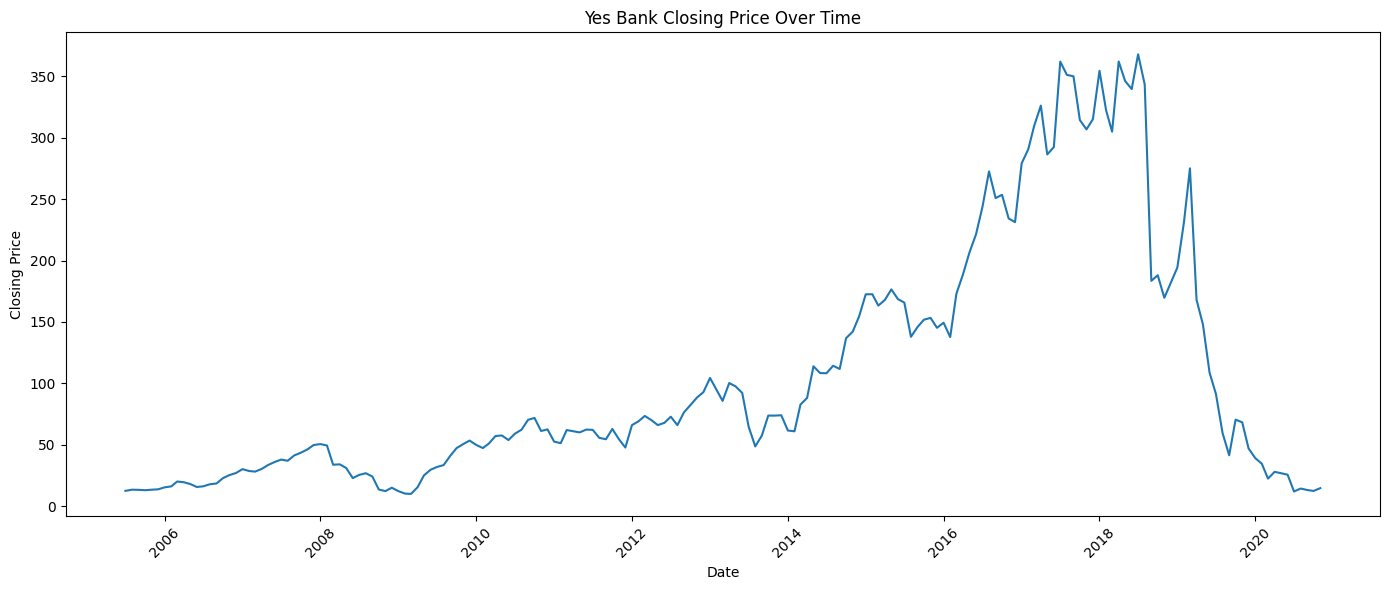

In [13]:
#closing price trand
plt.figure(figsize=(14, 6))

plt.plot(data["Date"], data["Close"])

plt.title("Yes Bank Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

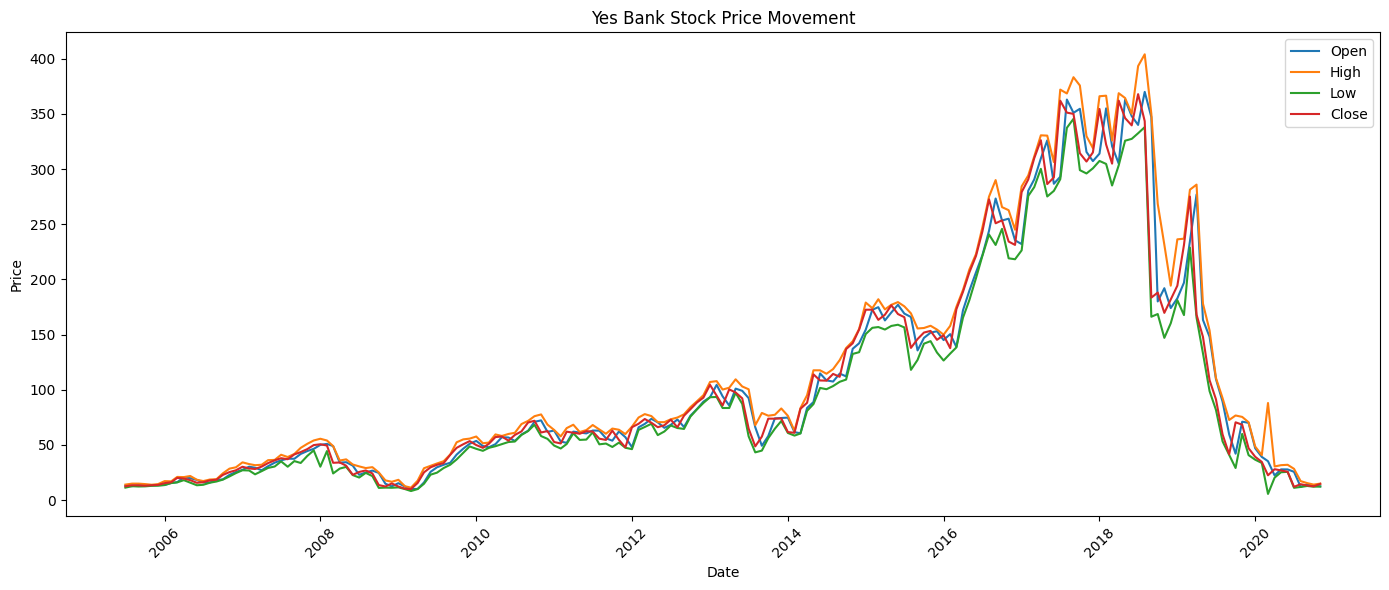

In [14]:
#check trend stock price movements
plt.figure(figsize=(14, 6))

plt.plot(data["Date"], data["Open"], label="Open")
plt.plot(data["Date"], data["High"], label="High")
plt.plot(data["Date"], data["Low"], label="Low")
plt.plot(data["Date"], data["Close"], label="Close")

plt.title("Yes Bank Stock Price Movement")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

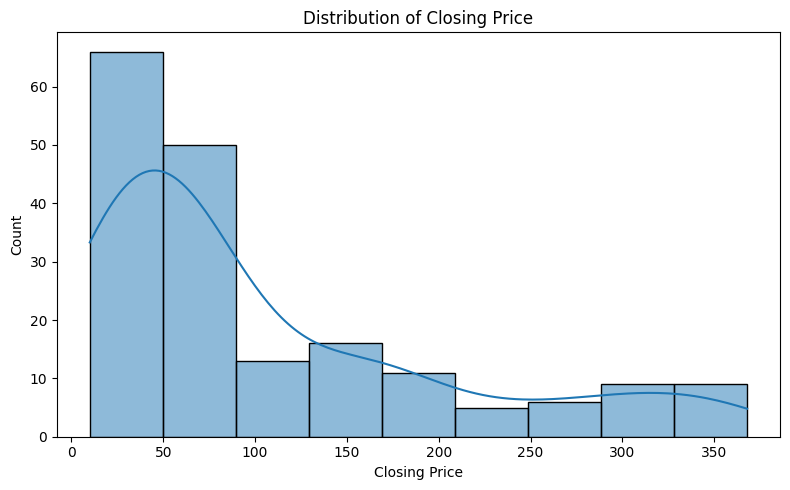

In [15]:
#Destribution of close
plt.figure(figsize=(8, 5))

sns.histplot(data["Close"], kde=True)

plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")

plt.tight_layout()
plt.show()

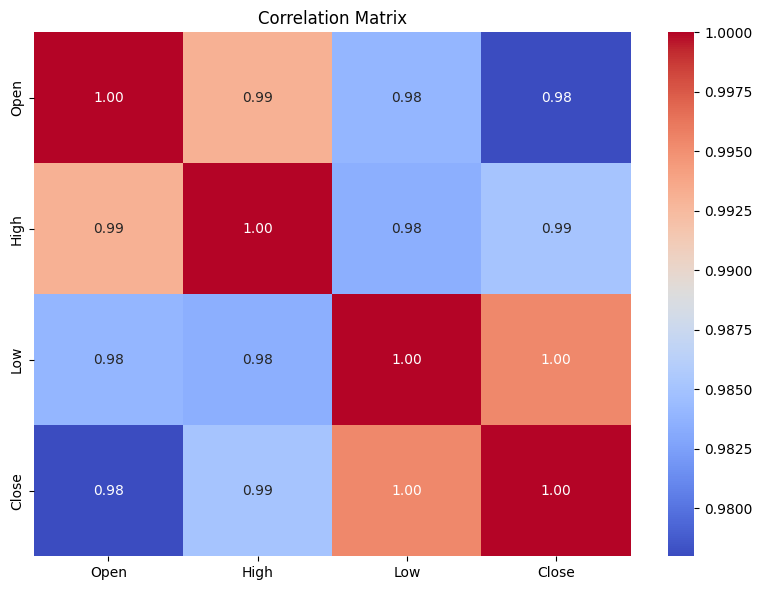

In [16]:
#Correlation analysis
plt.figure(figsize=(8, 6))

sns.heatmap(
    data[["Open", "High", "Low", "Close"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
#Feature Engineering 
#Next month clossing price
data["Target_Close"] = data["Close"].shift(-1)
print(data["Target_Close"].head())



0    13.42
1    13.30
2    12.99
3    13.41
4    13.71
Name: Target_Close, dtype: float64


185

In [19]:
#Lag Feature
#Clossing price for 1,3,6,9,12 moth 
for lag in [1,2,3,6,12]:
    data[f"Close_Lag_{lag}"] = (data["Close"].shift(lag))
    
    

#Moving Average

for window in [3,6,12]:
    data[f"Close_MA_{window}"]= (data["Close"].rolling(window).mean())
    

#Rolling standard deviation 
for window in [3,6,12]:
    data[f"Close_STD_{window}"] = (data["Close"].rolling(window).std())






In [20]:
#Monthly Return 
data["Return_1M"] = (data["Close"].pct_change())
print(data["Return_1M"].head())


0         NaN
1    0.077047
2   -0.008942
3   -0.023308
4    0.032333
Name: Return_1M, dtype: float64


In [21]:
#calender feature
data["Month"] = data["Date"].dt.month
print(data["Month"].head())
data["Year"] = data["Date"].dt.year
print(data["Year"])

0     7
1     8
2     9
3    10
4    11
Name: Month, dtype: int32
0      2005
1      2005
2      2005
3      2005
4      2005
       ... 
180    2020
181    2020
182    2020
183    2020
184    2020
Name: Year, Length: 185, dtype: int32


In [62]:
# ============================================================
# 5. REMOVE NaN
# ============================================================

data_model = data.dropna().copy()


In [24]:
#Feature & target
features = [
    "Close_Lag_1",
    "Close_Lag_2",
    "Close_Lag_3",
    "Close_Lag_6",
    "Close_Lag_12",
    "Close_MA_3",
    "Close_MA_6",
    "Close_MA_12",
    "Close_STD_3",
    "Close_STD_6",
    "Close_STD_12",
    "Return_1M",
    "Month",
    "Year"
]
print(features)

['Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_6', 'Close_Lag_12', 'Close_MA_3', 'Close_MA_6', 'Close_MA_12', 'Close_STD_3', 'Close_STD_6', 'Close_STD_12', 'Return_1M', 'Month', 'Year']


In [66]:
x = data_model[features]
print(len(x))
y = data_model["Target_Close"] 
print(len(y))

172
172


In [67]:
#text spliting
split_index = int(len(data_model) * 0.80)

X_train = x.iloc[:split_index]
X_test = x.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (137, 14)
Testing data: (35, 14)


linear regression



In [68]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
print(linear_model)

print("=========================================")



linear_pred = linear_model.predict(X_test)
print(len(y_test))
print(len(linear_pred))

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
35
35


Random Forest


In [69]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300, #tree size
    max_depth=6, #model stability
    min_samples_leaf=2, #reduce overfitting
    random_state=42 #controling the randomness
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print(rf_pred)

[321.75797079 326.21346376 319.11359849 322.11843421 326.4290663
 321.89313407 318.48277101 320.66595989 317.50341545 326.88515
 310.68193072 275.32143609 234.46739339 246.11227384 265.82539308
 274.31576425 279.46926635 241.96701437 207.21859355 169.76219378
 150.76884069 112.56215121 106.83828714 105.23691115  98.59232009
  95.04927951  88.25853268  58.14271738  54.02568761  52.01554226
  48.59635894  42.39131     43.96204466  42.11537749  40.80013695]


In [70]:
from sklearn.ensemble import GradientBoostingRegressor
#useing the gradientboosting to fix the mistake
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03, #learning from previous dataset
    max_depth=2,
    loss="huber",
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
print(gb_pred)

[298.36568295 321.44856456 309.07549414 313.62858976 327.54432026
 316.97117324 294.67826955 292.28629767 292.09360286 311.264703
 309.6420574  289.71776954 233.05953841 273.11743983 282.78744607
 277.59234427 275.73964307 249.50366664 208.36072137 189.81879509
 172.95627176 109.08476755 105.765791   103.10398262  90.06765302
  88.40394384  95.52965587  60.86643277  57.77731926  49.41680825
  41.79521681  35.83324683  46.47325825  35.30049414  36.65810909]


Model evaluation


In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [72]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("linear_pred:", linear_pred.shape)

X_test: (35, 14)
y_test: (35,)
linear_pred: (35,)


In [73]:
print(len(y_test))
print(len(linear_pred))

35
35


In [74]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)


Linear Regression
----------------------------------------
MAE  : 41.69
RMSE : 56.64
R2   : 0.7987

Random Forest
----------------------------------------
MAE  : 58.24
RMSE : 72.39
R2   : 0.6711

Gradient Boosting
----------------------------------------
MAE  : 60.79
RMSE : 74.64
R2   : 0.6504


Model Comparison


In [75]:
results_df = pd.DataFrame(results)

print(results_df)

               Model        MAE       RMSE        R2
0  Linear Regression  41.690881  56.636336  0.798721
1      Random Forest  58.244407  72.393117  0.671146
2  Gradient Boosting  60.789236  74.642417  0.650393


we can we that in above table **Linear Regresssion** is best fit model because it *MAE*, *RMSE*, is lower then compare to other model and R2 is higher then the other one. So we can say that **Linear Regression** good fit for this dataset

Best model

In [77]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


Actual vs predict

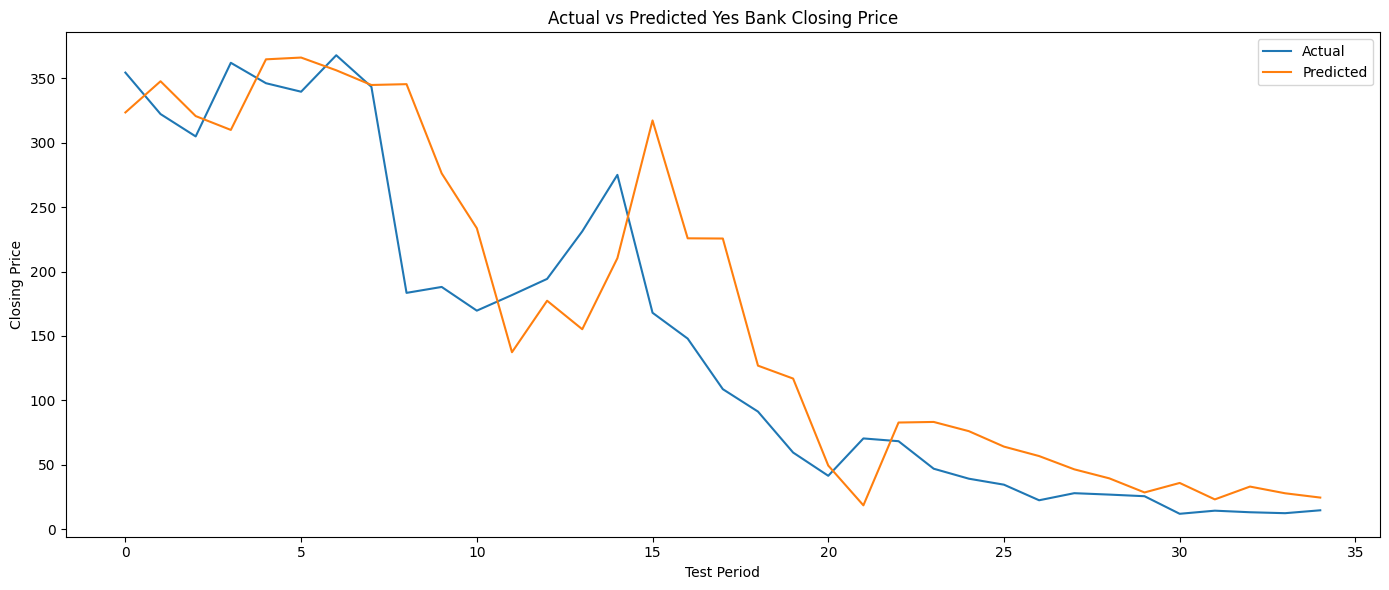

In [79]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    linear_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Yes Bank Closing Price")

plt.xlabel("Test Period")
plt.ylabel("Closing Price")

plt.legend()

plt.tight_layout()
plt.show()

date based graph

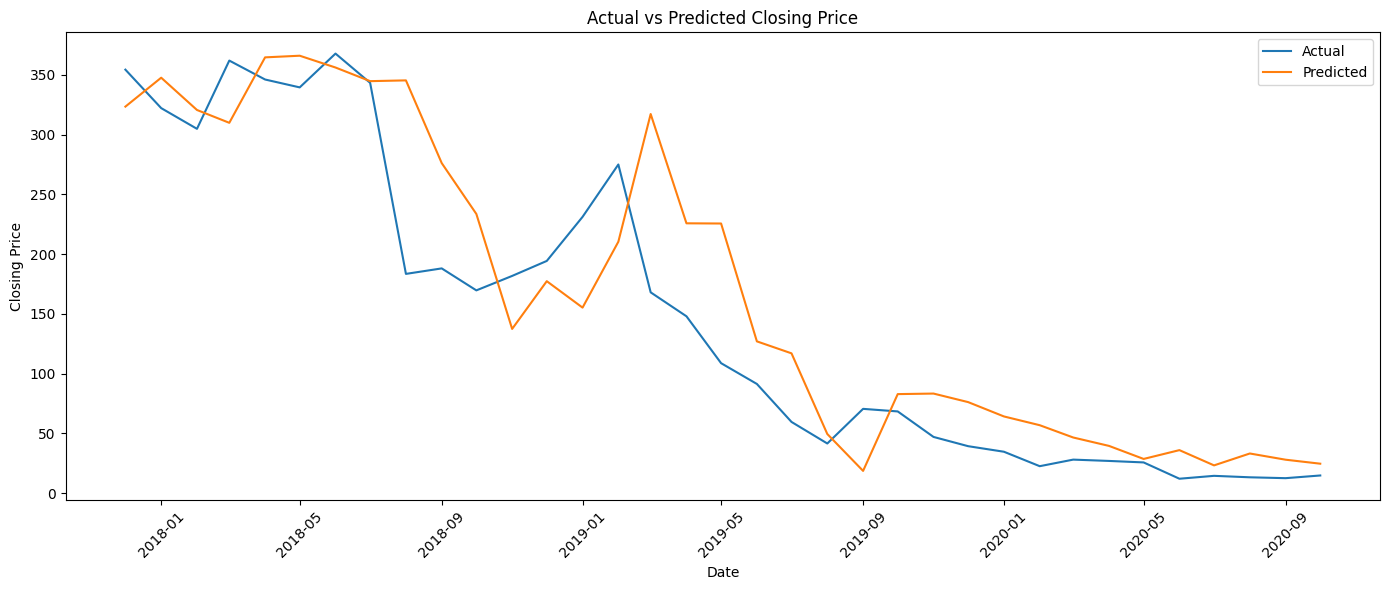

In [81]:
test_dates = data_model["Date"].iloc[split_index:]

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

plt.plot(
    test_dates,
    linear_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Closing Price")

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [84]:
print(linear_model)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])


In [93]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.named_steps["model"].coef_   #for extracting the LinearRegression model "linear_model.named_steps"
})

importance = importance.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

print(importance)

         Feature  Coefficient
5     Close_MA_3   173.590277
0    Close_Lag_1   -67.881588
1    Close_Lag_2   -55.971635
6     Close_MA_6    53.356446
7    Close_MA_12    33.826529
3    Close_Lag_6   -31.569361
2    Close_Lag_3   -23.248067
8    Close_STD_3     6.109665
9    Close_STD_6    -3.507097
13          Year     3.118189
4   Close_Lag_12    -1.977152
11     Return_1M     1.478380
10  Close_STD_12     0.613824
12         Month     0.610620


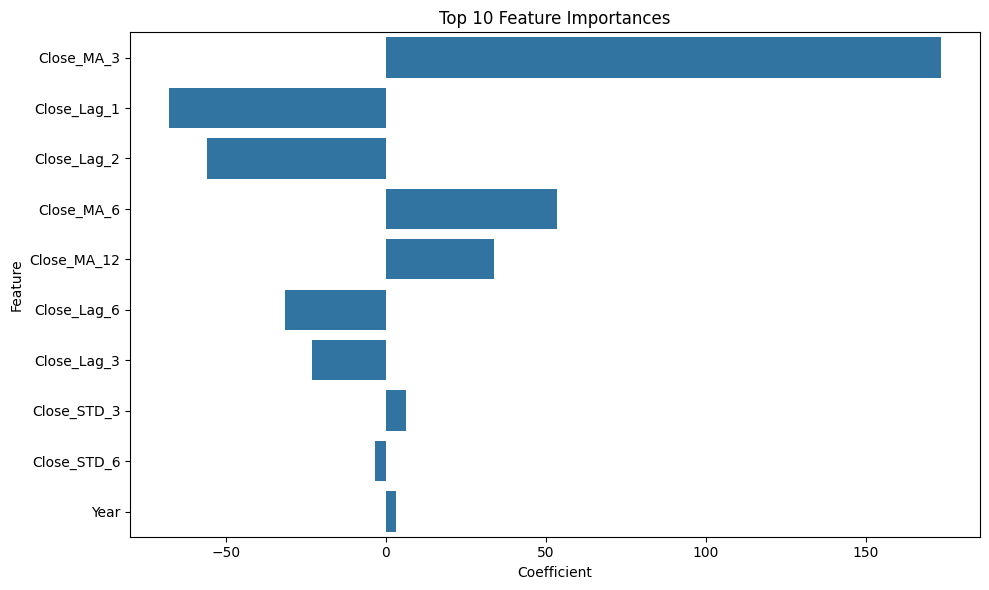

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5) #It creates chronological train/validation splits.

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
#GridSearchCV → tries different parameter combinations and finds the best one based on scoring metric.
param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False]
}

grid_search = GridSearchCV(
    estimator=linear_model,#use this model
    param_grid=param_grid,#This tells GridSearch which parameters to try.
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'model__fit_intercept': [True, False], 'model__positive': [True, False]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Best parameters

In [103]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__fit_intercept': True, 'model__positive': True}
Best CV RMSE:
14.47035980729748


Best model


In [105]:
best_linear_model = grid_search.best_estimator_
print(best_linear_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LinearRegression(positive=True))])


Predict

In [107]:
tuned_pred = best_linear_model.predict(X_test)
print(tuned_pred)

[302.05301156 342.01622478 332.61259116 335.53429508 352.78958054
 350.34022215 342.93642501 352.67159416 345.88798676 370.92553175
 327.12327015 181.36617895 187.95086277 194.014963   232.49220712
 276.91786861 257.95918539 259.52578403 161.23915579 140.96583825
 101.20766715  82.75748778 108.59920597  81.2107113   67.27507299
  67.34047277  49.57004742  34.50665517  54.13323808  36.05348413
  34.86074451  16.3580927   43.42236403  20.6260472   21.80735407]


Evaluate

In [108]:
evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_pred
)


Tuned Random Forest
----------------------------------------
MAE  : 46.79
RMSE : 68.28
R2   : 0.7075


{'Model': 'Tuned Random Forest',
 'MAE': 46.79415815126322,
 'RMSE': np.float64(68.27632415234449),
 'R2': 0.7074842507371601}

Save Model

In [110]:
import joblib

joblib.dump(
    best_linear_model,
    "yesbank_model.pkl"
)

joblib.dump(
    features,
    "yesbank_features.pkl"
)

print("Model saved successfully.")

Model saved successfully.


Save Processed Data

In [111]:
data_model.to_csv(
    "yesbank_processed_data.csv",
    index=False
)